In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
path = r"C:\Data_analysis\Thesis\Data\03_Training\Data_with_NaNs\15_min\df_BU_TotActPwr_Academy.parquet"
df = pd.read_parquet(path)


In [11]:
df.head()

,BU_TotActPwr_Academy,BA_Soc,PV_WS_AirTemp,PV_WS_Radiation,dayofweek,is_weekend,hour,sin_tod,cos_tod,sin_dow,...,BU_TotActPwr_Academy_roll_mean_96,BU_TotActPwr_Academy_roll_mean_288,BU_TotActPwr_Academy_roll_std_12,BU_TotActPwr_Academy_roll_std_24,BU_TotActPwr_Academy_roll_std_48,BU_TotActPwr_Academy_roll_std_96,BU_TotActPwr_Academy_trend_1_4,BU_TotActPwr_Academy_trend_1_12,BU_TotActPwr_Academy_trend_1_96,BU_TotActPwr_Academy_trend_96_192
Time,,,,,,,,,,,,,,,,,,,,,
2025-10-15 00:00:00,3.78367,83.36667,128.33333,-4.53333,2,0,0,0.000000,1.000000,0.974928,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-15 00:15:00,3.64667,83.10000,127.00000,-4.36667,2,0,0,0.065403,0.997859,0.974928,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-15 00:30:00,3.63033,82.80000,126.33333,-4.43333,2,0,0,0.130526,0.991445,0.974928,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-15 00:45:00,4.42467,82.56667,125.00000,-4.70000,2,0,0,0.195090,0.980785,0.974928,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-15 01:00:00,3.56700,82.26667,123.33333,-4.50000,2,0,1,0.258819,0.965926,0.974928,...,NaN,NaN,NaN,NaN,NaN,NaN,0.641,NaN,NaN,NaN


In [12]:

# Change this to your load column
TARGET_COL = "BU_TotActPwr_Academy"
# Keep only target column for profile analysis
load = pd.to_numeric(df[TARGET_COL], errors="coerce").to_frame(TARGET_COL)

print(load.head())
print(load.tail())
print(load.shape)
print(load.isna().mean() * 100)

                     BU_TotActPwr_Academy
Time                                     
2025-10-15 00:00:00               3.78367
2025-10-15 00:15:00               3.64667
2025-10-15 00:30:00               3.63033
2025-10-15 00:45:00               4.42467
2025-10-15 01:00:00               3.56700
                     BU_TotActPwr_Academy
Time                                     
2026-04-30 22:45:00               4.00867
2026-04-30 23:00:00               3.53167
2026-04-30 23:15:00               3.83100
2026-04-30 23:30:00               3.88900
2026-04-30 23:45:00               3.55167
(19008, 1)
BU_TotActPwr_Academy    9.87479
dtype: float64


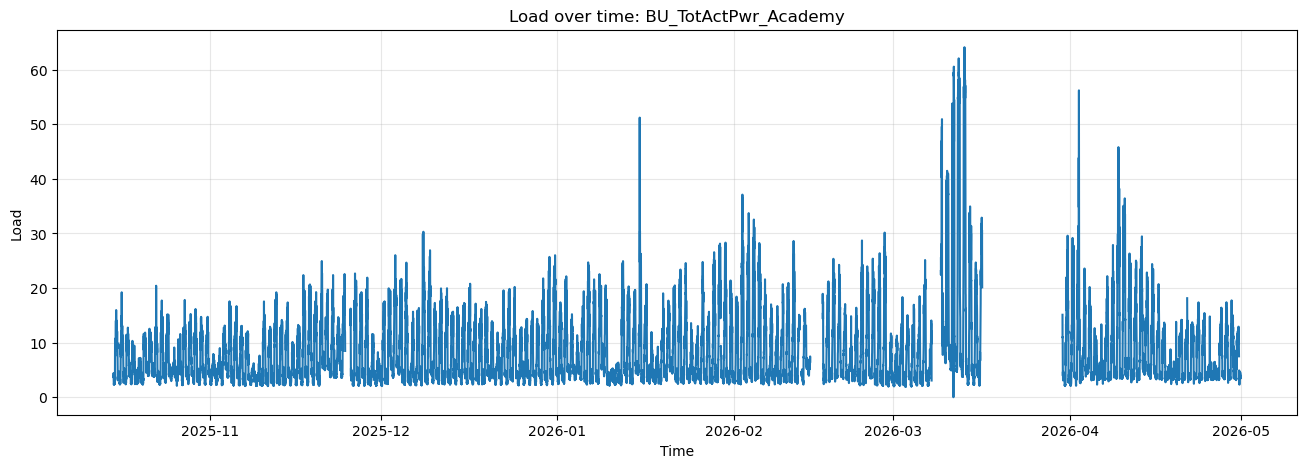

In [13]:
plt.figure(figsize=(16, 5))
plt.plot(load.index, load[TARGET_COL])
plt.title(f"Load over time: {TARGET_COL}")
plt.ylabel("Load")
plt.xlabel("Time")
plt.grid(True, alpha=0.3)
plt.show()

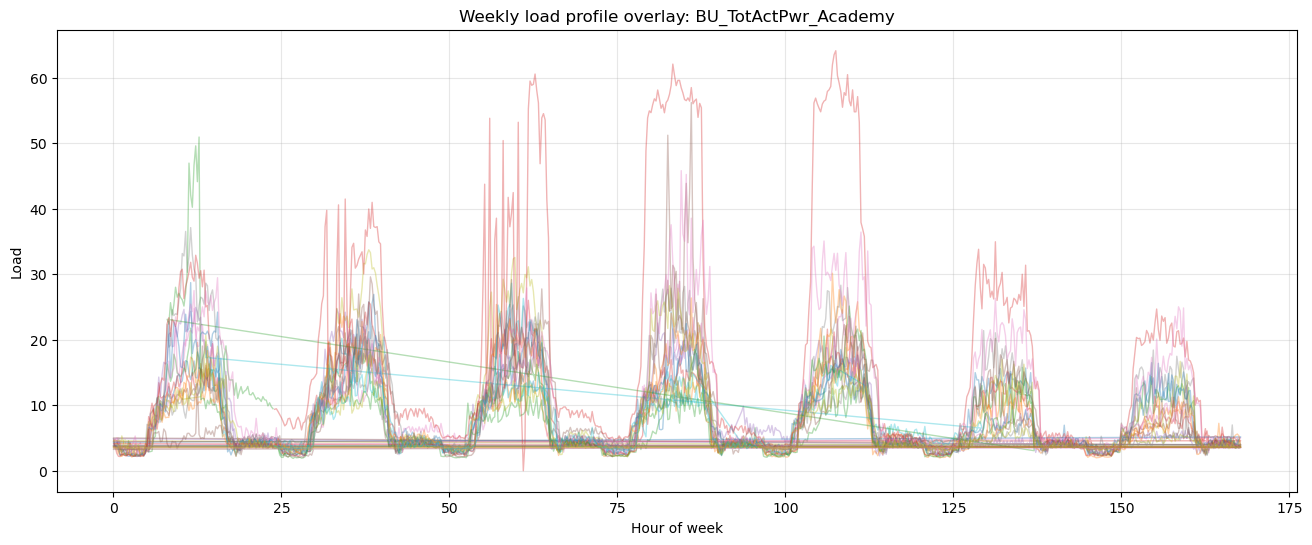

In [14]:
def plot_weekly_profiles(df, target_col, max_weeks=None):
    d = df[[target_col]].dropna().copy()
    
    # Start week on Monday
    d["week_start"] = d.index.to_period("W-MON").start_time
    d["minute_of_week"] = (
        d.index.dayofweek * 24 * 60
        + d.index.hour * 60
        + d.index.minute
    )
    
    weeks = sorted(d["week_start"].unique())
    if max_weeks is not None:
        weeks = weeks[-max_weeks:]
    
    plt.figure(figsize=(16, 6))
    
    for w in weeks:
        temp = d[d["week_start"] == w]
        plt.plot(
            temp["minute_of_week"] / 60,
            temp[target_col],
            alpha=0.35,
            linewidth=1
        )
    
    plt.title(f"Weekly load profile overlay: {target_col}")
    plt.xlabel("Hour of week")
    plt.ylabel("Load")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_weekly_profiles(load, TARGET_COL, max_weeks=20)

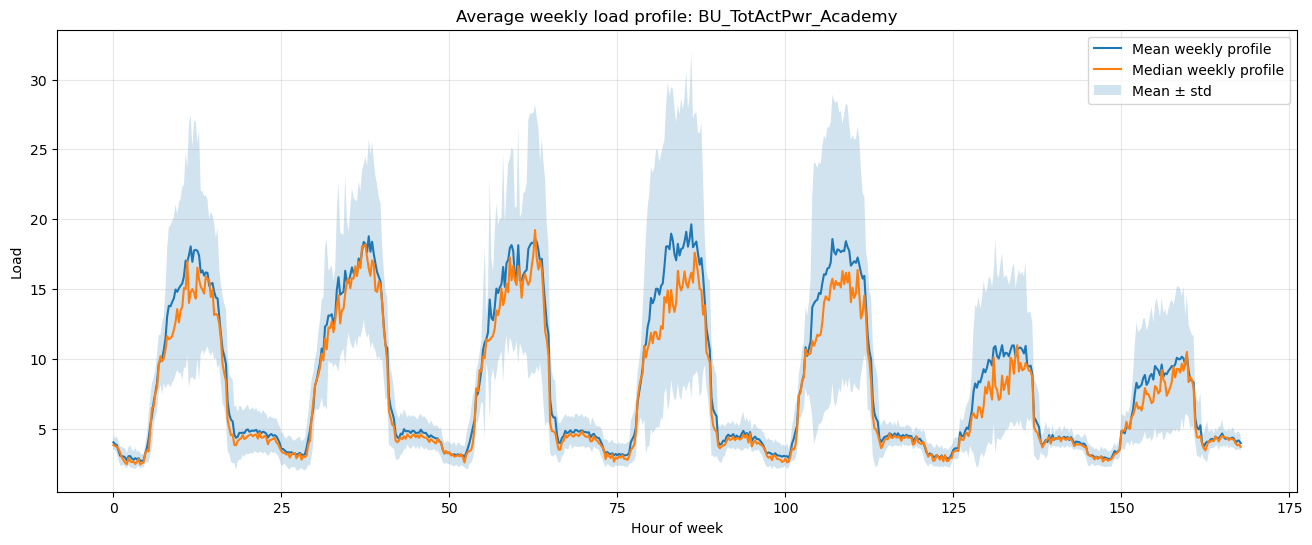

,mean,median,std,count,hour_of_week
slot,,,,,
0,4.024667,3.819835,0.548674,24,0.00
15,3.887125,3.775335,0.408687,24,0.25
30,3.828694,3.682835,0.632202,24,0.50
45,3.450958,3.563000,0.691128,24,0.75
60,3.064430,3.287335,0.687510,24,1.00


In [15]:
def average_weekly_profile(df, target_col):
    d = df[[target_col]].dropna().copy()
    
    d["dayofweek"] = d.index.dayofweek
    d["hour"] = d.index.hour
    d["minute"] = d.index.minute
    d["minute_of_day"] = d["hour"] * 60 + d["minute"]
    d["slot"] = d["dayofweek"] * 24 * 60 + d["minute_of_day"]
    
    profile = d.groupby("slot")[target_col].agg(["mean", "median", "std", "count"])
    profile["hour_of_week"] = profile.index / 60
    
    plt.figure(figsize=(16, 6))
    plt.plot(profile["hour_of_week"], profile["mean"], label="Mean weekly profile")
    plt.plot(profile["hour_of_week"], profile["median"], label="Median weekly profile")
    plt.fill_between(
        profile["hour_of_week"],
        profile["mean"] - profile["std"],
        profile["mean"] + profile["std"],
        alpha=0.2,
        label="Mean ± std"
    )
    
    plt.title(f"Average weekly load profile: {target_col}")
    plt.xlabel("Hour of week")
    plt.ylabel("Load")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return profile

weekly_profile = average_weekly_profile(load, TARGET_COL)
weekly_profile.head()

,weekly_mean,weekly_median,weekly_max,weekly_min,weekly_std,weekly_energy_sum,missing_pct
Time,,,,,,,
2025-10-19,5.769688,4.495835,19.22367,2.29700,3.121230,2769.45006,0.000000
2025-10-26,6.401574,5.252335,20.42600,2.08633,3.098686,4301.85752,0.000000
2025-11-02,6.272585,4.892165,17.82133,2.19600,3.449130,4202.63206,0.297619
2025-11-09,6.040814,4.524000,17.57000,2.04433,3.586611,4035.26373,0.595238
2025-11-16,6.587550,4.602835,19.22367,2.02667,4.017826,4426.83332,0.000000


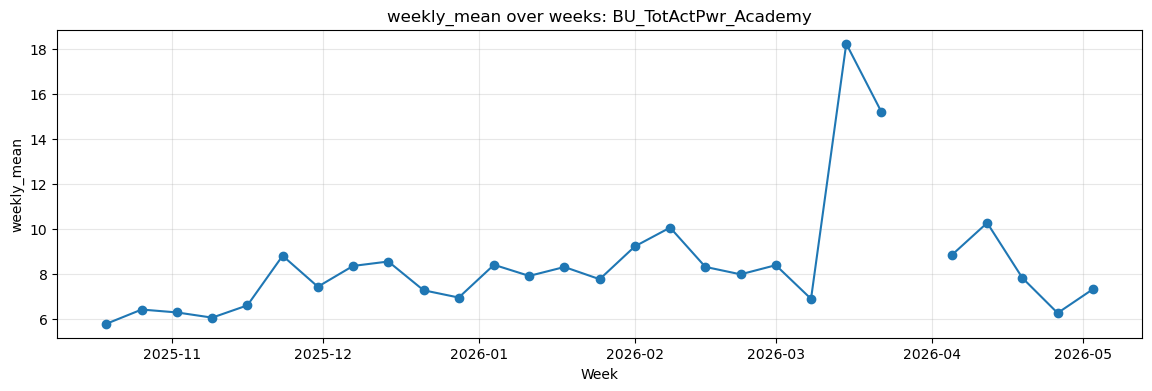

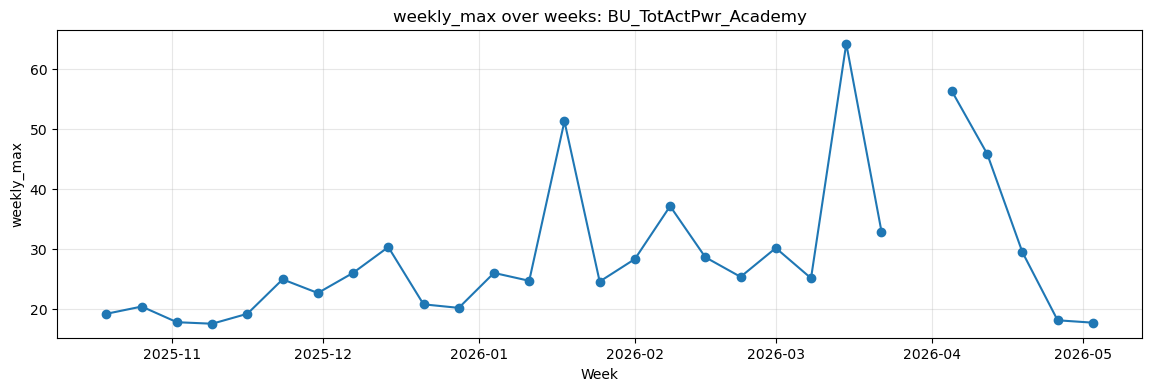

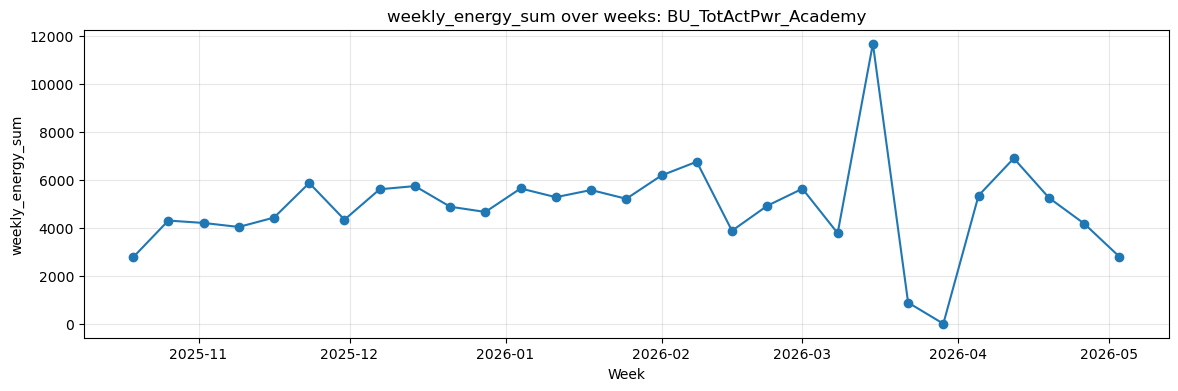

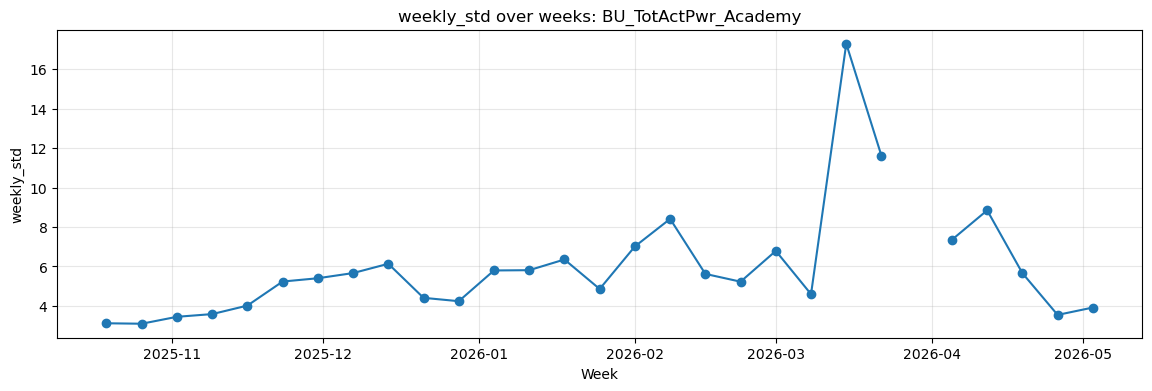

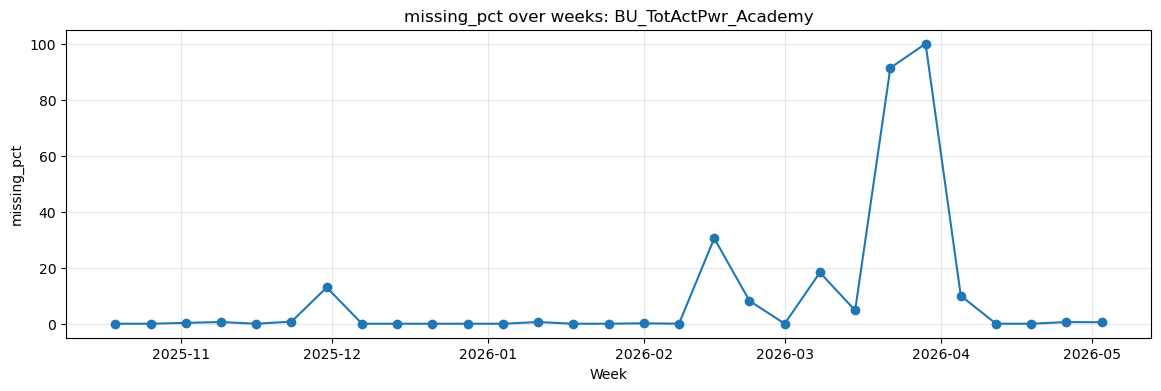

In [16]:
def weekly_summary(df, target_col):
    d = df[[target_col]].copy()
    
    weekly = d[target_col].resample("W").agg(
        weekly_mean="mean",
        weekly_median="median",
        weekly_max="max",
        weekly_min="min",
        weekly_std="std",
        weekly_energy_sum="sum",
        missing_pct=lambda x: x.isna().mean() * 100
    )
    
    return weekly

weekly_stats = weekly_summary(load, TARGET_COL)
display(weekly_stats.head())

figures = [
    "weekly_mean",
    "weekly_max",
    "weekly_energy_sum",
    "weekly_std",
    "missing_pct"
]

for col in figures:
    plt.figure(figsize=(14, 4))
    plt.plot(weekly_stats.index, weekly_stats[col], marker="o")
    plt.title(f"{col} over weeks: {TARGET_COL}")
    plt.xlabel("Week")
    plt.ylabel(col)
    plt.grid(True, alpha=0.3)
    plt.show()

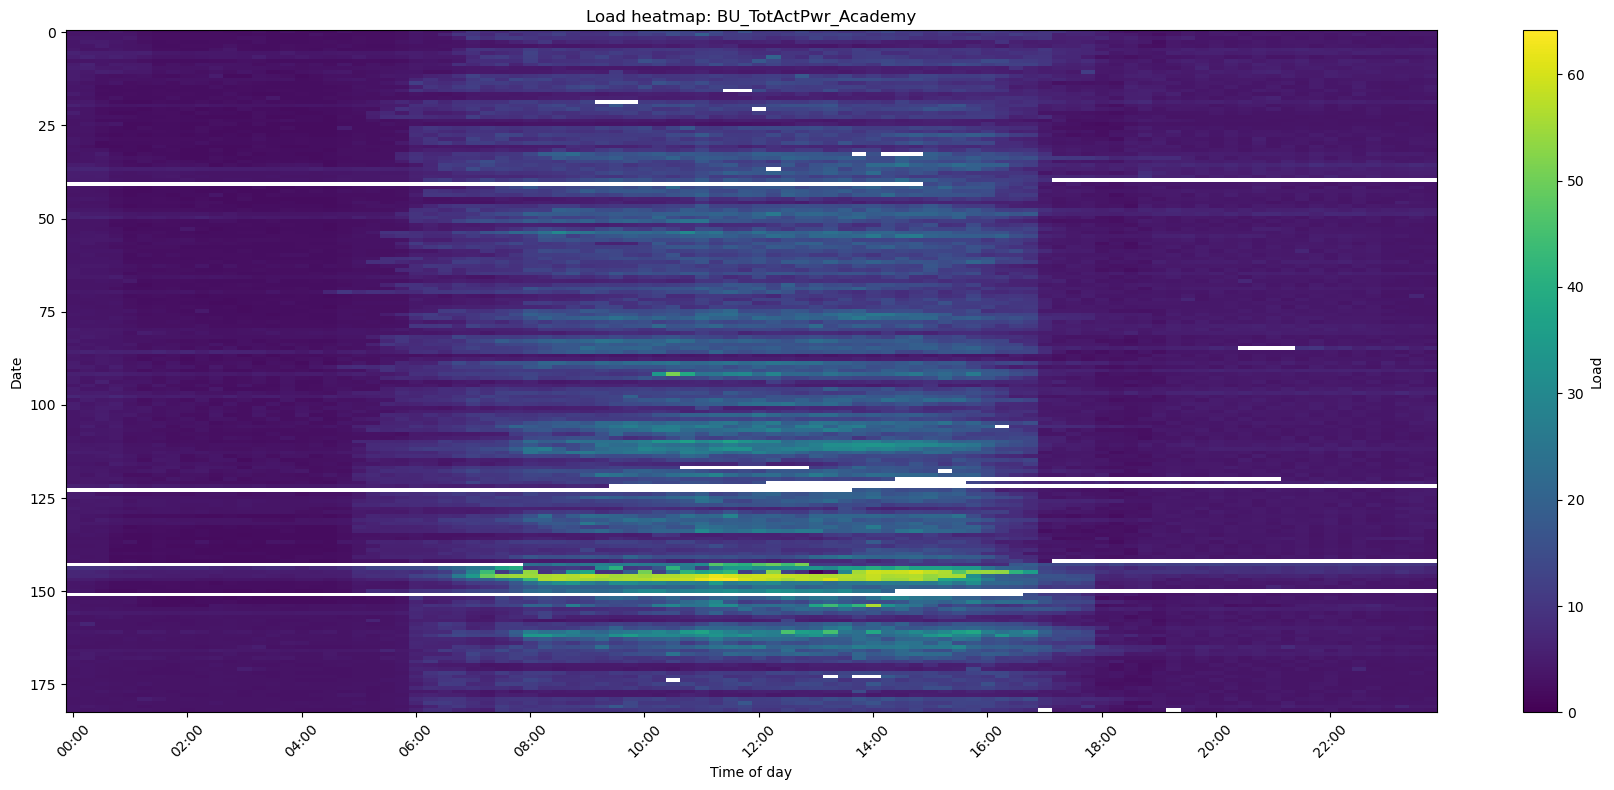

In [17]:
def plot_load_heatmap(df, target_col, freq="15min"):
    d = df[[target_col]].copy()
    d = d.resample(freq).mean()
    
    d["date"] = d.index.date
    d["time"] = d.index.strftime("%H:%M")
    
    pivot = d.pivot_table(
        index="date",
        columns="time",
        values=target_col,
        aggfunc="mean"
    )
    
    plt.figure(figsize=(18, 8))
    plt.imshow(pivot, aspect="auto", interpolation="nearest")
    plt.colorbar(label="Load")
    plt.title(f"Load heatmap: {target_col}")
    plt.xlabel("Time of day")
    plt.ylabel("Date")
    
    # reduce x labels
    step = max(1, len(pivot.columns) // 12)
    plt.xticks(
        ticks=np.arange(0, len(pivot.columns), step),
        labels=pivot.columns[::step],
        rotation=45
    )
    
    plt.tight_layout()
    plt.show()
    
    return pivot

heatmap_data = plot_load_heatmap(load, TARGET_COL)

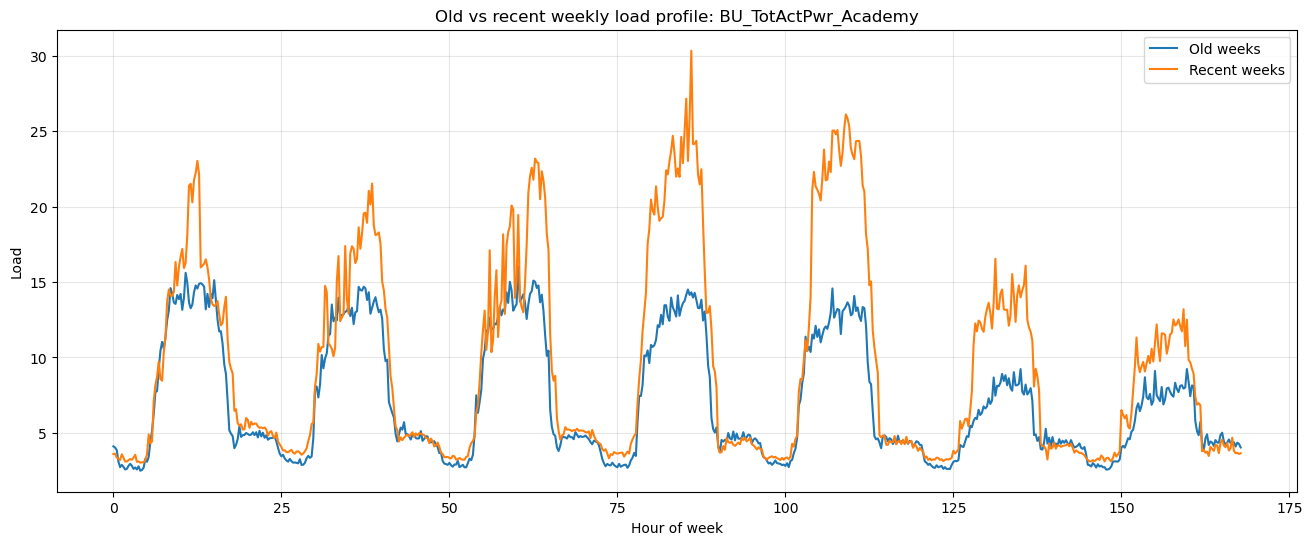

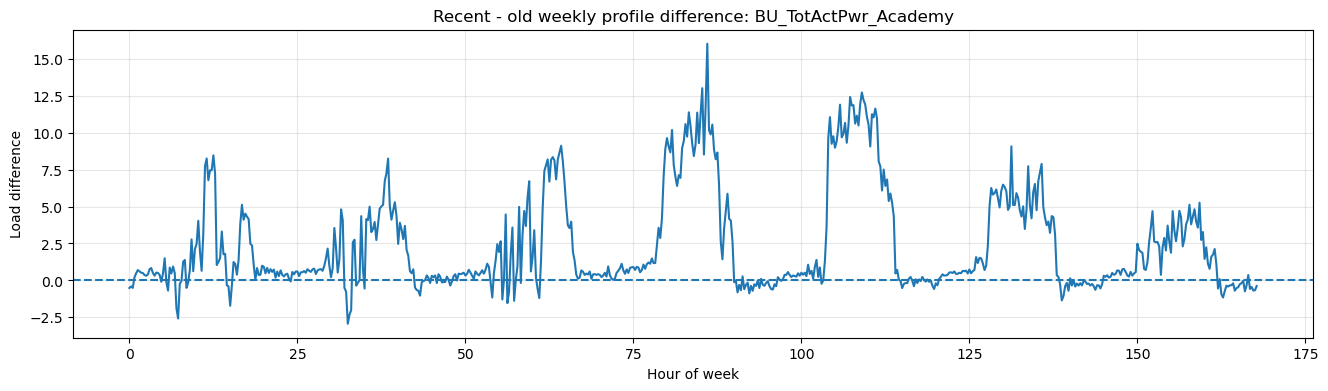

In [18]:
def compare_old_recent_weekly_profile(df, target_col, old_weeks=8, recent_weeks=8):
    d = df[[target_col]].dropna().copy()
    
    d["week_start"] = d.index.to_period("W-MON").start_time
    d["slot"] = (
        d.index.dayofweek * 24 * 60
        + d.index.hour * 60
        + d.index.minute
    )
    
    weeks = sorted(d["week_start"].unique())
    
    old_selected = weeks[:old_weeks]
    recent_selected = weeks[-recent_weeks:]
    
    old_profile = (
        d[d["week_start"].isin(old_selected)]
        .groupby("slot")[target_col]
        .mean()
    )
    
    recent_profile = (
        d[d["week_start"].isin(recent_selected)]
        .groupby("slot")[target_col]
        .mean()
    )
    
    comparison = pd.DataFrame({
        "old_profile": old_profile,
        "recent_profile": recent_profile
    })
    
    comparison["difference"] = comparison["recent_profile"] - comparison["old_profile"]
    comparison["hour_of_week"] = comparison.index / 60
    
    plt.figure(figsize=(16, 6))
    plt.plot(comparison["hour_of_week"], comparison["old_profile"], label="Old weeks")
    plt.plot(comparison["hour_of_week"], comparison["recent_profile"], label="Recent weeks")
    plt.title(f"Old vs recent weekly load profile: {target_col}")
    plt.xlabel("Hour of week")
    plt.ylabel("Load")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    plt.figure(figsize=(16, 4))
    plt.plot(comparison["hour_of_week"], comparison["difference"])
    plt.axhline(0, linestyle="--")
    plt.title(f"Recent - old weekly profile difference: {target_col}")
    plt.xlabel("Hour of week")
    plt.ylabel("Load difference")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return comparison

profile_change = compare_old_recent_weekly_profile(load, TARGET_COL)

In [19]:
import pandas as pd

def time_based_split_custom(
    df,
    train_ratio=0.80,
    val_ratio=0.10,
    test_ratio=0.10
):
    total = train_ratio + val_ratio + test_ratio
    
    if round(total, 5) != 1.0:
        raise ValueError(
            f"Ratios must sum to 1.0, but got {total}. "
            f"Current split is {train_ratio}, {val_ratio}, {test_ratio}"
        )
    
    df = df.sort_index().copy()
    
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = train_end + int(n * val_ratio)
    
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    
    return train_df, val_df, test_df


def summarize_split(train_df, val_df, test_df):
    rows = []
    
    for name, part in [
        ("Train", train_df),
        ("Validation", val_df),
        ("Test", test_df)
    ]:
        rows.append({
            "split": name,
            "rows": len(part),
            "percentage": len(part) / (len(train_df) + len(val_df) + len(test_df)) * 100,
            "start_time": part.index.min(),
            "end_time": part.index.max()
        })
    
    return pd.DataFrame(rows)

In [20]:
train_80, val_10, test_10 = time_based_split_custom(
    load,
    train_ratio=0.80,
    val_ratio=0.10,
    test_ratio=0.10
)

split_80_10_10_summary = summarize_split(train_80, val_10, test_10)
display(split_80_10_10_summary)

,split,rows,percentage,start_time,end_time
0,Train,15206,79.997896,2025-10-15 00:00:00,2026-03-22 09:15:00
1,Validation,1900,9.995791,2026-03-22 09:30:00,2026-04-11 04:15:00
2,Test,1902,10.006313,2026-04-11 04:30:00,2026-04-30 23:45:00


In [21]:
train_70, val_15, test_15 = time_based_split_custom(
    load,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15
)

split_70_15_15_summary = summarize_split(train_70, val_15, test_15)
display(split_70_15_15_summary)

,split,rows,percentage,start_time,end_time
0,Train,13305,69.996843,2025-10-15 00:00:00,2026-03-02 14:00:00
1,Validation,2851,14.998948,2026-03-02 14:15:00,2026-04-01 06:45:00
2,Test,2852,15.004209,2026-04-01 07:00:00,2026-04-30 23:45:00


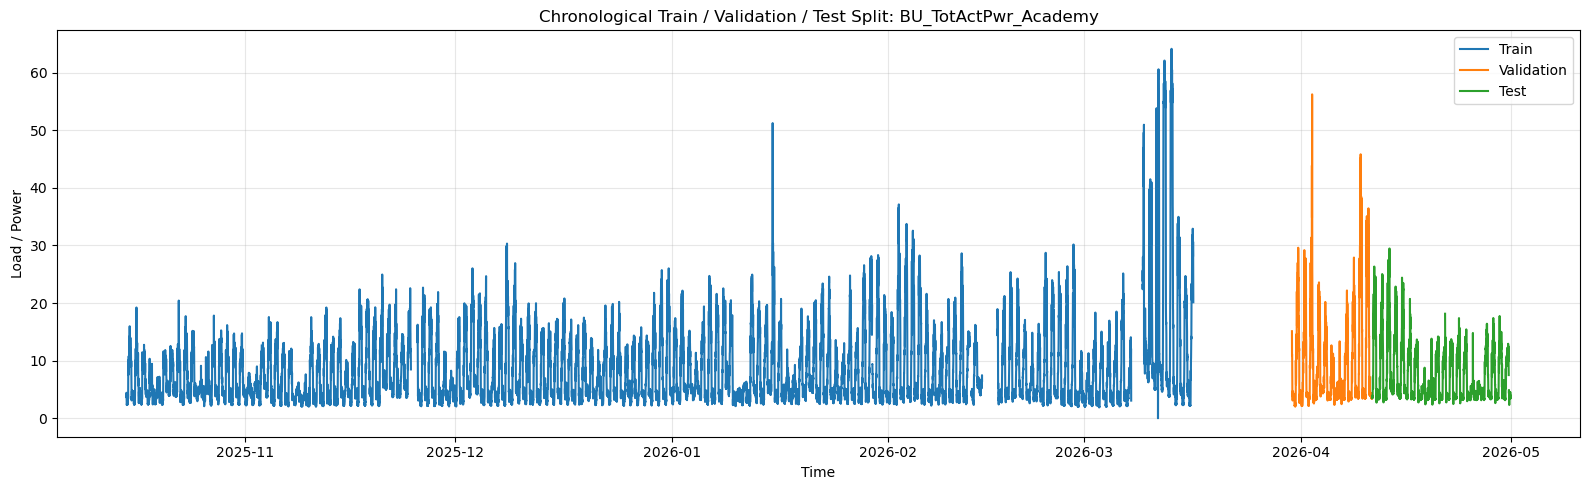

In [22]:
import matplotlib.pyplot as plt

def plot_split_distribution(df, train_df, val_df, test_df, target_col):
    plt.figure(figsize=(16, 5))
    
    plt.plot(train_df.index, train_df[target_col], label="Train")
    plt.plot(val_df.index, val_df[target_col], label="Validation")
    plt.plot(test_df.index, test_df[target_col], label="Test")
    
    plt.title(f"Chronological Train / Validation / Test Split: {target_col}")
    plt.xlabel("Time")
    plt.ylabel("Load / Power")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_split_distribution(load, train_80, val_10, test_10, TARGET_COL)

In [18]:
split_options = {
    "80_10_10": (0.80, 0.10, 0.10),
    "70_15_15": (0.70, 0.15, 0.15),
}

all_summaries = []

for split_name, ratios in split_options.items():
    tr, va, te = time_based_split_custom(
        load,
        train_ratio=ratios[0],
        val_ratio=ratios[1],
        test_ratio=ratios[2]
    )
    
    summary = summarize_split(tr, va, te)
    summary.insert(0, "split_ratio", split_name)
    all_summaries.append(summary)

all_split_summary = pd.concat(all_summaries, ignore_index=True)
display(all_split_summary)

,split_ratio,split,rows,percentage,start_time,end_time
0,80_10_10,Train,8755,79.998173,2025-10-18 00:00:00,2026-01-17 04:30:00
1,80_10_10,Validation,1094,9.996345,2026-01-17 04:45:00,2026-01-28 14:00:00
2,80_10_10,Test,1095,10.005482,2026-01-28 14:15:00,2026-02-08 23:45:00
3,70_15_15,Train,7660,69.992690,2025-10-18 00:00:00,2026-01-05 18:45:00
4,70_15_15,Validation,1641,14.994518,2026-01-05 19:00:00,2026-01-22 21:00:00
5,70_15_15,Test,1643,15.012792,2026-01-22 21:15:00,2026-02-08 23:45:00


In [33]:
train_df, val_df, test_df = time_based_split_custom(
    load,
    train_ratio=0.80,
    val_ratio=0.10,
    test_ratio=0.10
)

In [34]:
import pandas as pd
import numpy as np

def split_distribution_summary(train_df, val_df, test_df, target_col):
    rows = []

    total_rows = len(train_df) + len(val_df) + len(test_df)

    for split_name, part in [
        ("Train", train_df),
        ("Validation", val_df),
        ("Test", test_df)
    ]:
        s = pd.to_numeric(part[target_col], errors="coerce")

        rows.append({
            "split": split_name,
            "rows": len(part),
            "rows_%": len(part) / total_rows * 100,
            "start_time": part.index.min(),
            "end_time": part.index.max(),
            "missing_%": s.isna().mean() * 100,
            "mean": s.mean(),
            "median": s.median(),
            "std": s.std(),
            "min": s.min(),
            "q10": s.quantile(0.10),
            "q25": s.quantile(0.25),
            "q75": s.quantile(0.75),
            "q90": s.quantile(0.90),
            "max": s.max(),
            "sum": s.sum(),
            "zero_count": (s == 0).sum(),
            "near_zero_count_abs_lt_0.5": (s.abs() < 0.5).sum(),
            "near_zero_%_abs_lt_0.5": (s.abs() < 0.5).mean() * 100,
            "low_load_%_abs_lt_1.0": (s.abs() < 1.0).mean() * 100,
            "high_load_%_abs_gt_5.0": (s.abs() > 5.0).mean() * 100,
        })

    summary = pd.DataFrame(rows)

    numeric_cols = summary.select_dtypes(include="number").columns
    summary[numeric_cols] = summary[numeric_cols].round(3)

    return summary

dist_summary = split_distribution_summary(train_df, val_df, test_df, TARGET_COL)
display(dist_summary)

,split,rows,rows_%,start_time,end_time,missing_%,mean,median,std,min,...,q25,q75,q90,max,sum,zero_count,near_zero_count_abs_lt_0.5,near_zero_%_abs_lt_0.5,low_load_%_abs_lt_1.0,high_load_%_abs_gt_5.0
0,Train,15206,79.998,2025-10-15 00:00:00,2026-03-22 09:15:00,7.063,1.913,1.800,1.907,0.000,...,0.469,2.504,3.503,24.494,27028.100,10,3568,23.464,30.804,5.255
1,Validation,1900,9.996,2026-03-22 09:30:00,2026-04-11 04:15:00,41.947,2.504,2.505,2.635,0.163,...,0.662,2.513,4.682,22.099,2762.102,0,263,13.842,17.842,5.526
2,Test,1902,10.006,2026-04-11 04:30:00,2026-04-30 23:45:00,0.315,1.982,1.924,1.984,0.165,...,0.326,2.509,3.512,16.519,3758.085,0,547,28.759,34.648,5.836


C:\Users\MAVANI\AppData\Local\Temp\ipykernel_37800\6271548.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Train", "Validation", "Test"], showfliers=True)


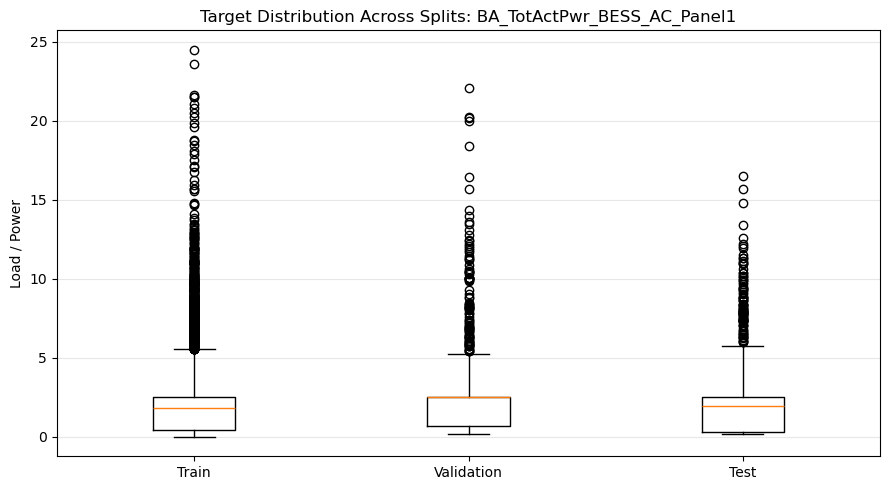

In [35]:
import matplotlib.pyplot as plt

def plot_split_boxplot(train_df, val_df, test_df, target_col):
    data = [
        pd.to_numeric(train_df[target_col], errors="coerce").dropna(),
        pd.to_numeric(val_df[target_col], errors="coerce").dropna(),
        pd.to_numeric(test_df[target_col], errors="coerce").dropna()
    ]

    plt.figure(figsize=(9, 5))
    plt.boxplot(data, labels=["Train", "Validation", "Test"], showfliers=True)
    plt.title(f"Target Distribution Across Splits: {target_col}")
    plt.ylabel("Load / Power")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_split_boxplot(train_df, val_df, test_df, TARGET_COL)

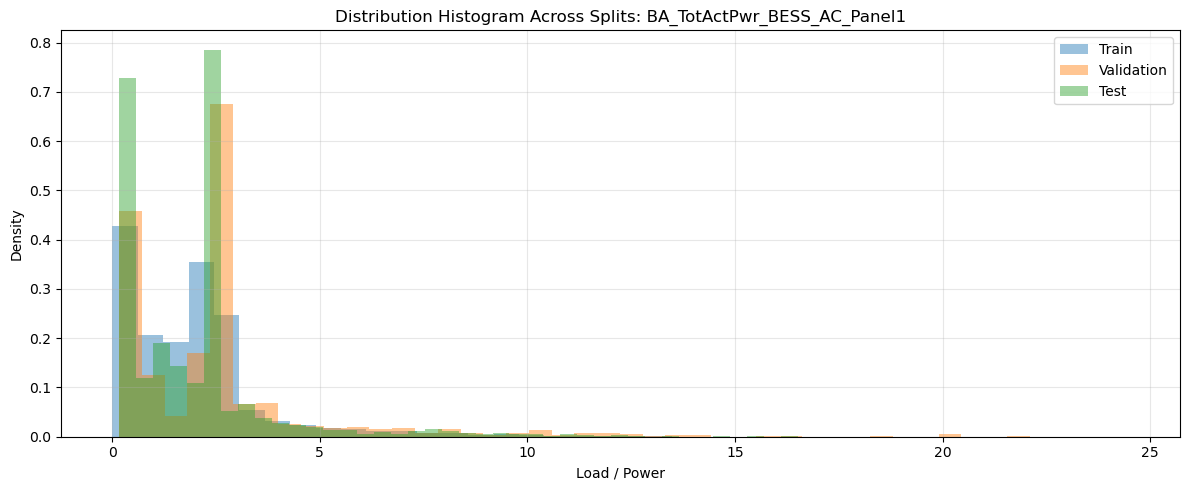

In [36]:
def plot_split_histograms(train_df, val_df, test_df, target_col, bins=40):
    plt.figure(figsize=(12, 5))

    for split_name, part in [
        ("Train", train_df),
        ("Validation", val_df),
        ("Test", test_df)
    ]:
        s = pd.to_numeric(part[target_col], errors="coerce").dropna()
        plt.hist(s, bins=bins, alpha=0.45, density=True, label=split_name)

    plt.title(f"Distribution Histogram Across Splits: {target_col}")
    plt.xlabel("Load / Power")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_split_histograms(train_df, val_df, test_df, TARGET_COL)

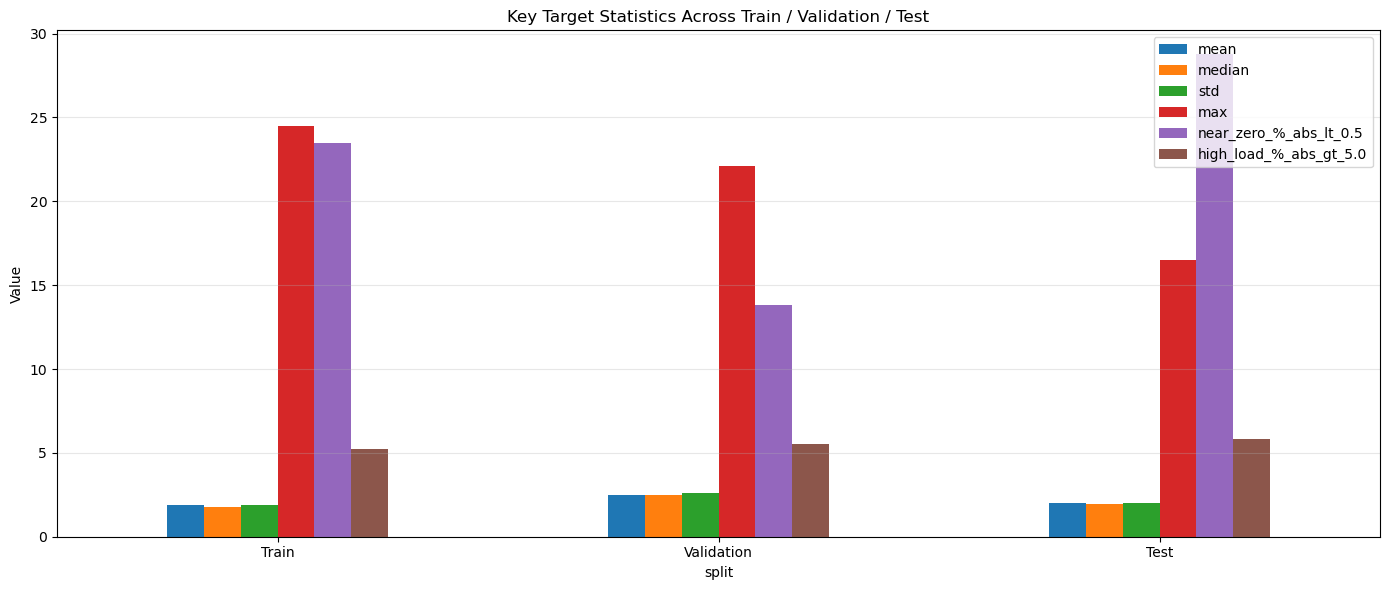

In [37]:
def plot_split_key_statistics(dist_summary):
    metrics = ["mean", "median", "std", "max", "near_zero_%_abs_lt_0.5", "high_load_%_abs_gt_5.0"]

    plot_df = dist_summary.set_index("split")[metrics]

    ax = plot_df.plot(kind="bar", figsize=(14, 6))
    ax.set_title("Key Target Statistics Across Train / Validation / Test")
    ax.set_ylabel("Value")
    ax.grid(True, axis="y", alpha=0.3)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_split_key_statistics(dist_summary)

In [38]:
def compare_split_ratios_distribution(df, target_col):
    split_options = {
        "80_10_10": (0.80, 0.10, 0.10),
        "70_15_15": (0.70, 0.15, 0.15),
    }

    all_rows = []

    for split_name, ratios in split_options.items():
        train_df, val_df, test_df = time_based_split_custom(
            df,
            train_ratio=ratios[0],
            val_ratio=ratios[1],
            test_ratio=ratios[2]
        )

        summary = split_distribution_summary(
            train_df,
            val_df,
            test_df,
            target_col
        )

        summary.insert(0, "split_ratio", split_name)
        all_rows.append(summary)

    result = pd.concat(all_rows, ignore_index=True)
    return result

all_split_distribution = compare_split_ratios_distribution(load, TARGET_COL)
display(all_split_distribution)

,split_ratio,split,rows,rows_%,start_time,end_time,missing_%,mean,median,std,...,q25,q75,q90,max,sum,zero_count,near_zero_count_abs_lt_0.5,near_zero_%_abs_lt_0.5,low_load_%_abs_lt_1.0,high_load_%_abs_gt_5.0
0,80_10_10,Train,15206,79.998,2025-10-15 00:00:00,2026-03-22 09:15:00,7.063,1.913,1.800,1.907,...,0.469,2.504,3.503,24.494,27028.100,10,3568,23.464,30.804,5.255
1,80_10_10,Validation,1900,9.996,2026-03-22 09:30:00,2026-04-11 04:15:00,41.947,2.504,2.505,2.635,...,0.662,2.513,4.682,22.099,2762.102,0,263,13.842,17.842,5.526
2,80_10_10,Test,1902,10.006,2026-04-11 04:30:00,2026-04-30 23:45:00,0.315,1.982,1.924,1.984,...,0.326,2.509,3.512,16.519,3758.085,0,547,28.759,34.648,5.836
3,70_15_15,Train,13305,69.997,2025-10-15 00:00:00,2026-03-02 14:00:00,2.728,1.833,1.727,1.706,...,0.466,2.501,3.329,18.106,23721.627,10,3337,25.081,32.446,4.885
4,70_15_15,Validation,2851,14.999,2026-03-02 14:15:00,2026-04-01 06:45:00,52.894,2.722,2.500,3.165,...,0.755,2.722,5.630,24.494,3655.725,0,274,9.611,14.416,5.577
5,70_15_15,Test,2852,15.004,2026-04-01 07:00:00,2026-04-30 23:45:00,0.210,2.168,2.215,2.268,...,0.463,2.510,3.955,22.099,6170.935,0,767,26.893,33.450,7.223


In [39]:
def plot_selected_weeks(df, target_col, selected_weeks):
    d = df[[target_col]].dropna().copy()
    d["week_start"] = d.index.to_period("W-MON").start_time
    d["hour_of_week"] = (
        d.index.dayofweek * 24
        + d.index.hour
        + d.index.minute / 60
    )
    
    plt.figure(figsize=(16, 6))
    
    for w in selected_weeks:
        temp = d[d["week_start"] == w]
        plt.plot(temp["hour_of_week"], temp[target_col], label=str(w.date()))
    
    plt.title(f"Abnormal weekly profiles: {target_col}")
    plt.xlabel("Hour of week")
    plt.ylabel("Load_KW")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_selected_weeks(load, TARGET_COL, abnormal_weeks.index[:5])

NameError: name 'abnormal_weeks' is not defined

In [66]:
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
FREQ = "30min"
# Optional: resample to make plots cleaner
load = df[[TARGET_COL]].resample(FREQ).mean()

print(load.head())
print(load.tail())
print(load.describe())

                     BU_TotActPwr_Academy
Time                                     
2025-10-18 00:00:00              4.286000
2025-10-18 00:30:00              4.488670
2025-10-18 01:00:00              3.268165
2025-10-18 01:30:00              2.505665
2025-10-18 02:00:00              2.464165
                     BU_TotActPwr_Academy
Time                                     
2026-02-08 21:30:00              4.395000
2026-02-08 22:00:00              4.333330
2026-02-08 22:30:00              4.157665
2026-02-08 23:00:00              3.748000
2026-02-08 23:30:00              4.210665
       BU_TotActPwr_Academy
count           5472.000000
mean               7.710524
std                5.410824
min                2.079170
25%                3.859169
50%                5.130915
75%               11.016666
max               44.954670


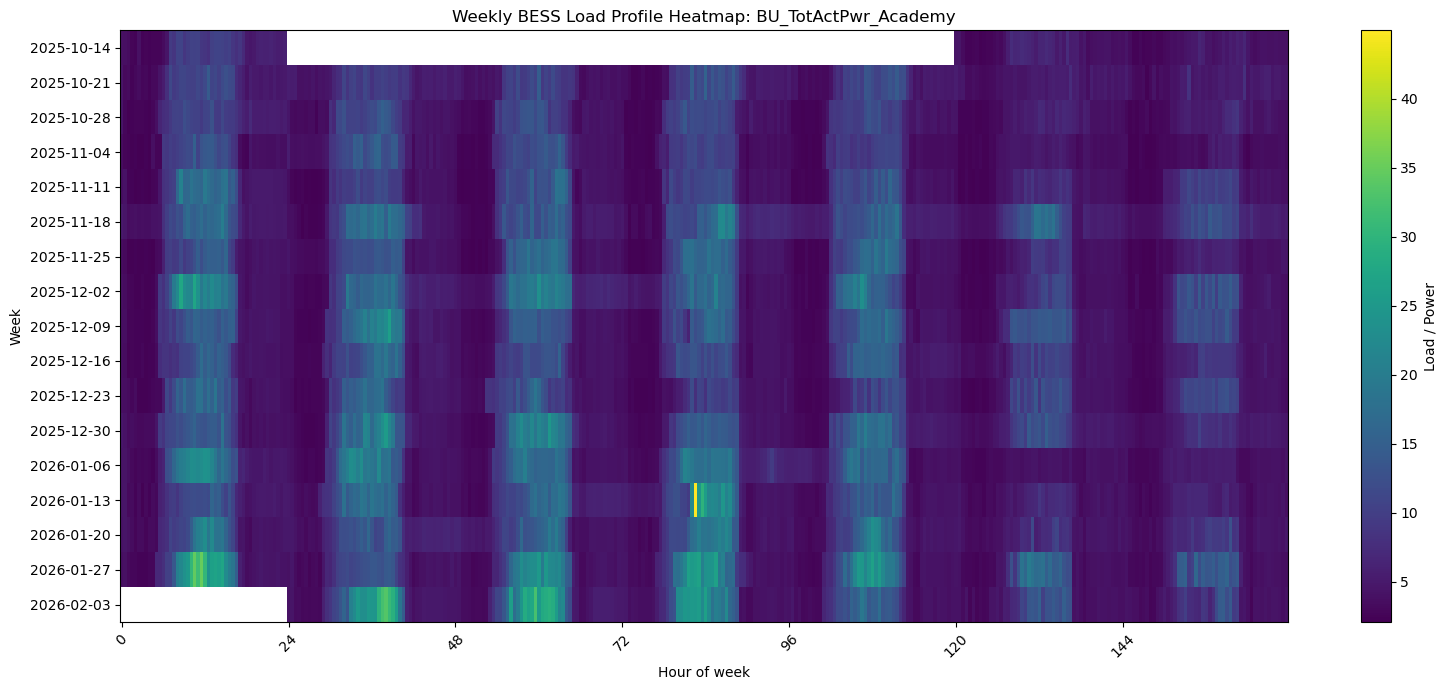

In [67]:
def plot_weekly_profile_heatmap(df, target_col, freq="30min"):
    d = df[[target_col]].copy()
    d = d.resample(freq).mean()

    d["week_start"] = d.index.to_period("W-MON").start_time
    d["hour_of_week"] = (
        d.index.dayofweek * 24
        + d.index.hour
        + d.index.minute / 60
    )

    weekly_matrix = d.pivot_table(
        index="week_start",
        columns="hour_of_week",
        values=target_col,
        aggfunc="mean"
    )

    plt.figure(figsize=(16, 7))
    plt.imshow(
        weekly_matrix,
        aspect="auto",
        interpolation="nearest"
    )

    plt.colorbar(label="Load / Power")
    plt.title(f"Weekly BESS Load Profile Heatmap: {target_col}")
    plt.xlabel("Hour of week")
    plt.ylabel("Week")

    # x-axis every 24 hours
    x_ticks = np.arange(0, len(weekly_matrix.columns), max(1, int(24 / (pd.to_timedelta(freq).total_seconds() / 3600))))
    x_labels = [int(weekly_matrix.columns[i]) for i in x_ticks]
    plt.xticks(x_ticks, x_labels, rotation=45)

    # y-axis week labels
    y_ticks = np.arange(len(weekly_matrix.index))
    y_labels = [str(pd.to_datetime(w).date()) for w in weekly_matrix.index]
    plt.yticks(y_ticks, y_labels)

    plt.tight_layout()
    plt.show()

    return weekly_matrix

weekly_matrix = plot_weekly_profile_heatmap(load, TARGET_COL, freq=FREQ)

In [40]:
def plot_typical_weekly_profile(df, target_col, freq="30min"):
    d = df[[target_col]].copy()
    d = d.resample(freq).mean()

    d["hour_of_week"] = (
        d.index.dayofweek * 24
        + d.index.hour
        + d.index.minute / 60
    )

    profile = d.groupby("hour_of_week")[target_col].agg(
        mean="mean",
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        q10=lambda x: x.quantile(0.10),
        q90=lambda x: x.quantile(0.90),
        count="count"
    )

    x = profile.index

    plt.figure(figsize=(16, 5))

    plt.plot(x, profile["median"], linewidth=2.5, label="Median weekly profile")
    plt.plot(x, profile["mean"], linewidth=1.5, linestyle="--", label="Mean weekly profile")

    plt.fill_between(
        x,
        profile["q25"],
        profile["q75"],
        alpha=0.25,
        label="25–75% range"
    )

    plt.fill_between(
        x,
        profile["q10"],
        profile["q90"],
        alpha=0.15,
        label="10–90% range"
    )

    plt.title(f"Typical Weekly Profile with Variability: {target_col}")
    plt.xlabel("Hour of week")
    plt.ylabel("Load / Power")
    plt.xticks(np.arange(0, 169, 24))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return profile

typical_profile = plot_typical_weekly_profile(load, TARGET_COL, freq=FREQ)

NameError: name 'FREQ' is not defined

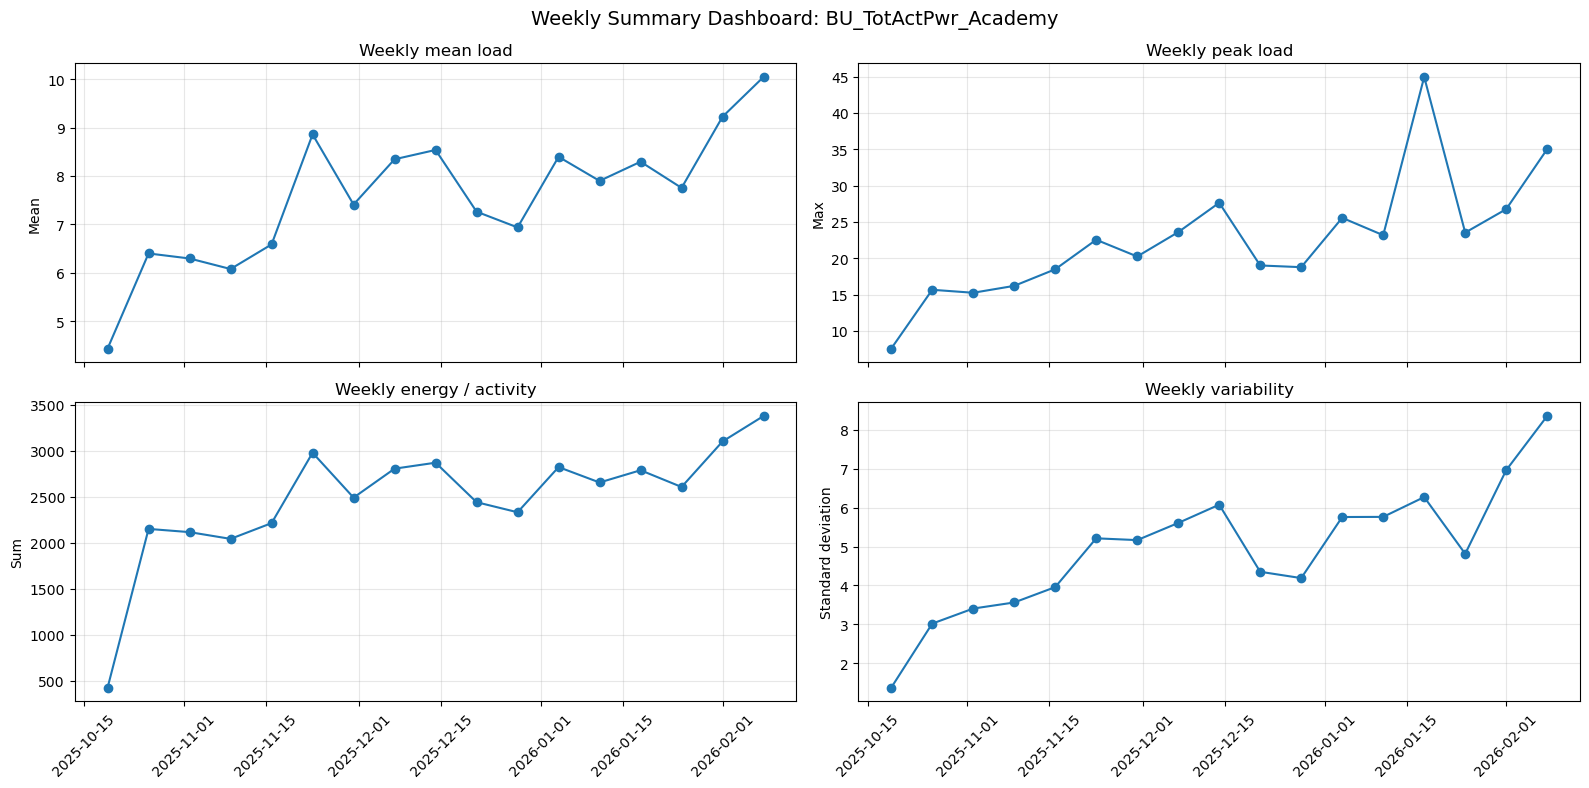

,weekly_mean,weekly_max,weekly_energy_sum,weekly_std,weekly_min,missing_pct
Time,,,,,,
2025-10-19,4.429924,7.552670,425.272675,1.369307,2.408000,0.0
2025-10-26,6.397428,15.653000,2149.535760,3.017322,2.286500,0.0
2025-11-02,6.293317,15.242665,2114.554615,3.404664,2.257170,0.0
2025-11-09,6.075483,16.192170,2041.362365,3.561117,2.099000,0.0
2025-11-16,6.584006,18.472835,2212.226160,3.956179,2.079170,0.0
2025-11-23,8.858381,22.537835,2976.416172,5.211170,2.220665,0.0
2025-11-30,7.408482,20.235500,2489.249989,5.165151,2.122335,0.0
2025-12-07,8.344472,23.586500,2803.742505,5.605996,2.199000,0.0
2025-12-14,8.537200,27.629000,2868.499345,6.076188,2.285000,0.0


In [69]:
def plot_weekly_summary_dashboard(df, target_col):
    weekly = df[target_col].resample("W").agg(
        weekly_mean="mean",
        weekly_max="max",
        weekly_energy_sum="sum",
        weekly_std="std",
        weekly_min="min",
        missing_pct=lambda x: x.isna().mean() * 100
    )

    fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)

    axes[0, 0].plot(weekly.index, weekly["weekly_mean"], marker="o")
    axes[0, 0].set_title("Weekly mean load")
    axes[0, 0].set_ylabel("Mean")

    axes[0, 1].plot(weekly.index, weekly["weekly_max"], marker="o")
    axes[0, 1].set_title("Weekly peak load")
    axes[0, 1].set_ylabel("Max")

    axes[1, 0].plot(weekly.index, weekly["weekly_energy_sum"], marker="o")
    axes[1, 0].set_title("Weekly energy / activity")
    axes[1, 0].set_ylabel("Sum")

    axes[1, 1].plot(weekly.index, weekly["weekly_std"], marker="o")
    axes[1, 1].set_title("Weekly variability")
    axes[1, 1].set_ylabel("Standard deviation")

    for ax in axes.ravel():
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis="x", rotation=45)

    fig.suptitle(f"Weekly Summary Dashboard: {target_col}", fontsize=14)
    plt.tight_layout()
    plt.show()

    return weekly

weekly_stats = plot_weekly_summary_dashboard(load, TARGET_COL)
display(weekly_stats)